# Acceso a datos diarios de contaminación en el municipio de Madrid

El municipio de Madrid tiene muchos datos en abierto. Veamos cómo acceder a los datos de contaminación del día actual para mostrar una gráfica resumen sobre los óxidos de nitrógeno (NOx) en la estación de Plaza de España.

La página con toda la información sobre estos datos se encuentra en: https://datos.madrid.es/dataset/212531-0-calidad-aire-tiempo-real. Vemos que es posible acceder a los datos en formato JSON, XML y CSV. Además, es importante leerse el documento explicativo "**INTÉRPRETE DE FICHEROS DE DATOS**" disponible en https://datos.madrid.es/dataset/212531-0-calidad-aire-tiempo-real/resource/212531-4-calidad-aire-tiempo-real para entender el formato.

Vemos que cada fila representa una estación concreta y un contaminante concreto en el día actual. Tanto los contaminantes como las estaciones tienen un código que se explica en el documento "**INTÉRPRETE DE FICHEROS DE DATOS**", por ejemplo:

* Pza. de España: 28079**004** --> estación `4` en el campo `ESTACION` del  CSV
* Cuatro Caminos: 28079**038** --> estación `38` en el campo `ESTACION` del  CSV
* Retiro: 28079**049** --> estación 49 en el campo `ESTACION` del  CSV
* ...

De la misma manera, cada contaminante tiene un código que también se explica en el documento "**INTÉRPRETE DE FICHEROS DE DATOS**":
* Dióxido de Azufre: contaminante `1` en el campo `MAGNITUD` del CSV
* Monóxido de Carbono: contaminante `6` en el campo `MAGNITUD` del CSV
* Monóxido de Nitrógeno: contaminante `7` en el campo `MAGNITUD` del CSV
* Óxidos de Nitrógeno: contaminante `12` en el campo `MAGNITUD` del CSV
* ...

En cada fila hay 48 columnas que indican la medición de cada hora y su código de validación. Por ejemplo, la medición a la 1:00h está almacenada en la columna `H01` y el código de validación en `V01`. El fichero contiene hasta las columnas `H24` y `V24`. La columna de validación de cada hora contendrá `V` si el dato es válido y `N` si no lo es.

Nuestro objetivo es dibujar un diagrama de líneas mostrando la variación horaria los óxidos de nitrógeno (NOx) en la estación de Plaza de España. Para ellos tendremos que:
1. Acceder al fichero CSV
2. Analizarlo con Python (biblioteca `csv`) para poder acceder con facilidad a sus datos
3. Crear un DataFrame resumen con los datos válidos
4. Dibujar el diagrama con seaborn a partir del DataFrame

In [1]:
import requests
import csv
import pandas as pd
import seaborn as sns

# Cabeceras de las columnas que me interesan
# H01;V01;H02;V02;H03;V03;H04;V04;H05;V05;H06;V06;H07;V07;H08;V08;H09;V09;H10;V10;H11;V11;H12;V12;H13;V13;H14;V14;H15;V15;H16;V16;H17;V17;H18;V18;H19;V19;H20;V20;H21;V21;H22;V22;H23;V23;H24;V24
# Creo una lista de parejas (hora, validación)
cabeceras = [ ('H0'+str(i), 'V0'+str(i)) if i < 10 
              else ('H'+str(i), 'V'+str(i)) 
                for i in range(1, 25) ]
print(cabeceras)
print()


def df_from_row(row):
    """ Extrae la hora y valor contaminación (si es válido) y generamos un DataFrame """
    rows = [ [hora, float(row[hora]) ] for (hora, val) in cabeceras if row[val] == 'V']
    df = pd.DataFrame(rows, columns=['hora','valor'])
    return df


# Si os falla al descargar el fichero con requests.get(), podéis descargarlo a mano y 
# abrirlo como un fichero de texto normal con open()
## Versión requests
#url = 'http://datos.madrid.es/dataset/212531-0-calidad-aire-tiempo-real/resource/212531-2-calidad-aire-tiempo-real/download/212531-2-calidad-aire-tiempo-real.csv'
#resp = requests.get(url)
#file = io.StringIO(resp.text)  # Creamos un objeto file-like desde una cadena de texto
## Versión con fichero
file = open('calidad-aire-tiempo-real.csv', 'r', encoding='utf-8')

csv_reader = csv.DictReader(file, delimiter=';')  # Leemos cada línea como un diccionario
for row in csv_reader:
    if row['ESTACION'] == '4' and row['MAGNITUD'] == '12':
        # NOx
        df_nox = df_from_row(row)
        break

print(df_nox.dtypes)
display(df_nox)

[('H01', 'V01'), ('H02', 'V02'), ('H03', 'V03'), ('H04', 'V04'), ('H05', 'V05'), ('H06', 'V06'), ('H07', 'V07'), ('H08', 'V08'), ('H09', 'V09'), ('H10', 'V10'), ('H11', 'V11'), ('H12', 'V12'), ('H13', 'V13'), ('H14', 'V14'), ('H15', 'V15'), ('H16', 'V16'), ('H17', 'V17'), ('H18', 'V18'), ('H19', 'V19'), ('H20', 'V20'), ('H21', 'V21'), ('H22', 'V22'), ('H23', 'V23'), ('H24', 'V24')]

hora         str
valor    float64
dtype: object


,hora,valor
0,H01,25.0
1,H02,60.0
2,H03,77.0
3,H04,42.0
4,H05,27.0
5,H06,20.0
6,H07,28.0
7,H08,32.0
8,H09,54.0
9,H10,74.0


Text(0.5, 1.0, 'Niveles de contaminación en Plaza de España')

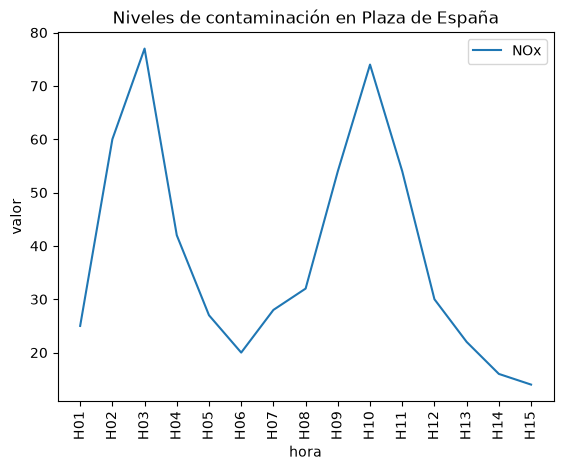

In [2]:
import matplotlib.pyplot as plt

sns.lineplot(data=df_nox, x="hora", y="valor")
plt.legend(labels=["NOx"])
plt.xticks(rotation=90)
plt.title('Niveles de contaminación en Plaza de España')